In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [69]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler,TargetEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv("cancer_reg.csv")

In [6]:
df.head()

,avganncount,avgdeathsperyear,target_deathrate,incidencerate,medincome,popest2015,povertypercent,studypercap,binnedinc,medianage,...,pctprivatecoveragealone,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


In [8]:
df.columns

Index(['avganncount', 'avgdeathsperyear', 'target_deathrate', 'incidencerate',
       'medincome', 'popest2015', 'povertypercent', 'studypercap', 'binnedinc',
       'medianage', 'medianagemale', 'medianagefemale', 'geography',
       'percentmarried', 'pctnohs18_24', 'pcths18_24', 'pctsomecol18_24',
       'pctbachdeg18_24', 'pcths25_over', 'pctbachdeg25_over',
       'pctemployed16_over', 'pctunemployed16_over', 'pctprivatecoverage',
       'pctprivatecoveragealone', 'pctempprivcoverage', 'pctpubliccoverage',
       'pctpubliccoveragealone', 'pctwhite', 'pctblack', 'pctasian',
       'pctotherrace', 'pctmarriedhouseholds', 'birthrate'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   str    
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   str    
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24             3047 non-n

In [11]:
df["binnedinc"].value_counts()

binnedinc
(54545.6, 61494.5]    306
[22640, 34218.1]      306
(45201, 48021.6]      306
(48021.6, 51046.4]    305
(42724.4, 45201]      305
(51046.4, 54545.6]    305
(37413.8, 40362.7]    304
(40362.7, 42724.4]    304
(34218.1, 37413.8]    304
(61494.5, 125635]     302
Name: count, dtype: int64

In [12]:
df.shape

(3047, 33)

In [16]:
df_new=df.drop("binnedinc",axis=1)

In [17]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   medianage                3047 non-null   float64
 9   medianagemale            3047 non-null   float64
 10  medianagefemale          3047 non-null   float64
 11  geography                3047 non-null   str    
 12  percentmarried           3047 non-null   float64
 13  pctnohs18_24             3047 non-null   float64
 14  pcths18_24               3047 non-n

In [18]:
df_new["geography"].value_counts()

geography
Kitsap County, Washington       1
Kittitas County, Washington     1
Klickitat County, Washington    1
Lewis County, Washington        1
Lincoln County, Washington      1
                               ..
Ellsworth County, Kansas        1
Finney County, Kansas           1
Ford County, Kansas             1
Franklin County, Kansas         1
Geary County, Kansas            1
Name: count, Length: 3047, dtype: int64

In [19]:
df_new.isnull().sum()

avganncount                   0
avgdeathsperyear              0
target_deathrate              0
incidencerate                 0
medincome                     0
popest2015                    0
povertypercent                0
studypercap                   0
medianage                     0
medianagemale                 0
medianagefemale               0
geography                     0
percentmarried                0
pctnohs18_24                  0
pcths18_24                    0
pctsomecol18_24            2285
pctbachdeg18_24               0
pcths25_over                  0
pctbachdeg25_over             0
pctemployed16_over          152
pctunemployed16_over          0
pctprivatecoverage            0
pctprivatecoveragealone     609
pctempprivcoverage            0
pctpubliccoverage             0
pctpubliccoveragealone        0
pctwhite                      0
pctblack                      0
pctasian                      0
pctotherrace                  0
pctmarriedhouseholds          0
birthrat

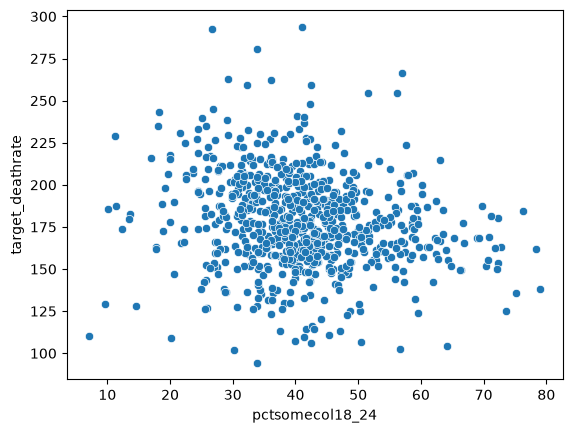

In [20]:
sns.scatterplot(x=df_new["pctsomecol18_24"],y=df_new["target_deathrate"])
plt.show()

In [21]:
cols = ["pctnohs18_24", "pcths18_24", "pctsomecol18_24", "pctbachdeg18_24"]
tot = df_new[cols].sum(axis=1)
print(tot.describe())   # dolu satırlarda ~100 mü?

count    3047.000000
mean       69.632425
std        19.935830
min        21.700000
25%        55.900000
50%        64.000000
75%        99.900000
max       100.100000
dtype: float64


In [22]:
df_new["pctsomecol18_24"] = df_new["pctsomecol18_24"].fillna(
    100 - df_new[["pctnohs18_24", "pcths18_24", "pctbachdeg18_24"]].sum(axis=1)
)

In [23]:
df_new.isnull().sum()

avganncount                  0
avgdeathsperyear             0
target_deathrate             0
incidencerate                0
medincome                    0
popest2015                   0
povertypercent               0
studypercap                  0
medianage                    0
medianagemale                0
medianagefemale              0
geography                    0
percentmarried               0
pctnohs18_24                 0
pcths18_24                   0
pctsomecol18_24              0
pctbachdeg18_24              0
pcths25_over                 0
pctbachdeg25_over            0
pctemployed16_over         152
pctunemployed16_over         0
pctprivatecoverage           0
pctprivatecoveragealone    609
pctempprivcoverage           0
pctpubliccoverage            0
pctpubliccoveragealone       0
pctwhite                     0
pctblack                     0
pctasian                     0
pctotherrace                 0
pctmarriedhouseholds         0
birthrate                    0
dtype: i

In [24]:
df_new["pctemployed16_over"] = df_new["pctemployed16_over"].fillna(
    df_new["pctemployed16_over"].median()
)

In [25]:
print(df_new[["pctprivatecoverage", "pctprivatecoveragealone"]].corr())

                         pctprivatecoverage  pctprivatecoveragealone
pctprivatecoverage                 1.000000                 0.933496
pctprivatecoveragealone            0.933496                 1.000000


In [27]:
m = df_new["pctprivatecoveragealone"].notna()
lr = LinearRegression().fit(
    df_new.loc[m, ["pctprivatecoverage"]],
    df_new.loc[m, "pctprivatecoveragealone"]
)
df_new.loc[~m, "pctprivatecoveragealone"] = lr.predict(
    df_new.loc[~m, ["pctprivatecoverage"]]
)

df_new["pctprivatecoveragealone"] = df_new["pctprivatecoveragealone"].clip(0, 100)

In [28]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   medianage                3047 non-null   float64
 9   medianagemale            3047 non-null   float64
 10  medianagefemale          3047 non-null   float64
 11  geography                3047 non-null   str    
 12  percentmarried           3047 non-null   float64
 13  pctnohs18_24             3047 non-null   float64
 14  pcths18_24               3047 non-n

In [29]:
df_new.isnull().sum()

avganncount                0
avgdeathsperyear           0
target_deathrate           0
incidencerate              0
medincome                  0
popest2015                 0
povertypercent             0
studypercap                0
medianage                  0
medianagemale              0
medianagefemale            0
geography                  0
percentmarried             0
pctnohs18_24               0
pcths18_24                 0
pctsomecol18_24            0
pctbachdeg18_24            0
pcths25_over               0
pctbachdeg25_over          0
pctemployed16_over         0
pctunemployed16_over       0
pctprivatecoverage         0
pctprivatecoveragealone    0
pctempprivcoverage         0
pctpubliccoverage          0
pctpubliccoveragealone     0
pctwhite                   0
pctblack                   0
pctasian                   0
pctotherrace               0
pctmarriedhouseholds       0
birthrate                  0
dtype: int64

In [31]:
df_new["geography"].value_counts()

geography
Kitsap County, Washington       1
Kittitas County, Washington     1
Klickitat County, Washington    1
Lewis County, Washington        1
Lincoln County, Washington      1
                               ..
Ellsworth County, Kansas        1
Finney County, Kansas           1
Ford County, Kansas             1
Franklin County, Kansas         1
Geary County, Kansas            1
Name: count, Length: 3047, dtype: int64

In [32]:
df_new["geography"].str.split(",")

0          [Kitsap County,  Washington]
1        [Kittitas County,  Washington]
2       [Klickitat County,  Washington]
3           [Lewis County,  Washington]
4         [Lincoln County,  Washington]
                     ...               
3042        [Ellsworth County,  Kansas]
3043           [Finney County,  Kansas]
3044             [Ford County,  Kansas]
3045         [Franklin County,  Kansas]
3046            [Geary County,  Kansas]
Name: geography, Length: 3047, dtype: object

In [33]:
df_new["geography"].str.strip()

0          Kitsap County, Washington
1        Kittitas County, Washington
2       Klickitat County, Washington
3           Lewis County, Washington
4         Lincoln County, Washington
                    ...             
3042        Ellsworth County, Kansas
3043           Finney County, Kansas
3044             Ford County, Kansas
3045         Franklin County, Kansas
3046            Geary County, Kansas
Name: geography, Length: 3047, dtype: str

In [34]:
df_new["geography"].str.split(",")

0          [Kitsap County,  Washington]
1        [Kittitas County,  Washington]
2       [Klickitat County,  Washington]
3           [Lewis County,  Washington]
4         [Lincoln County,  Washington]
                     ...               
3042        [Ellsworth County,  Kansas]
3043           [Finney County,  Kansas]
3044             [Ford County,  Kansas]
3045         [Franklin County,  Kansas]
3046            [Geary County,  Kansas]
Name: geography, Length: 3047, dtype: object

In [42]:
df_new["state"] = df_new["geography"].str.split(",").str[1].str.strip()

In [43]:
df_new["state"]

0       Washington
1       Washington
2       Washington
3       Washington
4       Washington
           ...    
3042        Kansas
3043        Kansas
3044        Kansas
3045        Kansas
3046        Kansas
Name: state, Length: 3047, dtype: object

In [44]:
df_new["state"].unique()

array(['Washington', 'West Virginia', 'Wisconsin', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'Virginia', 'Michigan', 'Minnesota', 'North Carolina',
       'North Dakota', 'Alabama', 'Arkansas', 'California', 'Montana',
       'Tennessee', 'Texas', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Utah', 'Vermont', 'Colorado', 'Wyoming',
       'Mississippi', 'Missouri', 'Kansas', 'Kentucky', 'Connecticut',
       'Delaware', 'District of Columbia', 'Florida', 'Oklahoma',
       'Oregon', 'Ohio', 'Pennsylvania', 'Rhode Island', 'South Carolina',
       'Indiana', 'Iowa', 'Georgia', 'Hawaii', 'Idaho', 'Illinois',
       'Alaska', 'Arizona', 'South Dakota'], dtype=object)

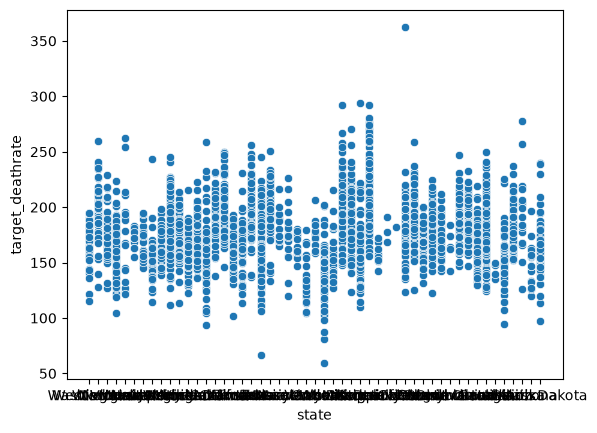

In [45]:
sns.scatterplot(x=df_new["state"],y=df_new["target_deathrate"])
plt.show()

In [48]:
df_new.groupby("state")["target_deathrate"].mean().sort_values()

state
Utah                    135.751852
Colorado                141.561667
Hawaii                  142.975000
Arizona                 149.086667
Idaho                   154.202381
New Mexico              156.181250
Connecticut             157.712500
California              158.096491
Wyoming                 158.986957
North Dakota            160.360784
Nebraska                160.553750
Minnesota               161.481609
Montana                 163.185417
South Dakota            163.545763
Massachusetts           164.800000
Rhode Island            165.220000
Iowa                    166.488889
Washington              166.492308
Kansas                  167.834314
New Jersey              168.633333
Oregon                  170.288889
New Hampshire           170.880000
Texas                   171.585408
New York                171.640323
Wisconsin               172.373611
Pennsylvania            175.422388
Vermont                 176.271429
Maryland                176.479167
Nevada        

In [49]:
df_new["geography"].unique()

<ArrowStringArray>
[      'Kitsap County, Washington',     'Kittitas County, Washington',
    'Klickitat County, Washington',        'Lewis County, Washington',
      'Lincoln County, Washington',        'Mason County, Washington',
     'Okanogan County, Washington',      'Pacific County, Washington',
 'Pend Oreille County, Washington',       'Pierce County, Washington',
 ...
         'Doniphan County, Kansas',          'Douglas County, Kansas',
          'Edwards County, Kansas',              'Elk County, Kansas',
            'Ellis County, Kansas',        'Ellsworth County, Kansas',
           'Finney County, Kansas',             'Ford County, Kansas',
         'Franklin County, Kansas',            'Geary County, Kansas']
Length: 3047, dtype: str

In [51]:
df_new["geography"] = df_new["geography"].str.split(",").str[0].str.strip()

In [57]:
X = df_new.drop(["geography","target_deathrate"],axis=1)
y = df_new["target_deathrate"]

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [64]:
target = TargetEncoder(random_state=15)
X_train["state"] = target.fit_transform(X_train[["state"]], y_train)
X_test["state"] = target.transform(X_test[["state"]])

/Users/caferkosker/anaconda3/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [65]:
X_train["state"].head()
X_train.dtypes.value_counts()   # artık object kalmamalı

float64    28
int64       3
Name: count, dtype: int64

In [67]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
param = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "max_depth": [4, 5, 6, 7, 8, 10, 12],
    "min_samples_leaf": [1, 5, 10, 20, 30, 50],
    "min_samples_split": [2, 10, 20]
}

In [ ]:
grid = GridSearchCV(estimator=DecisionTreeRegressor(),param_grid=param,cv=5,scoring="r2")
warnings.filterwarnings("ignore")
grid.fit(X_train_scaled,y_train)

In [81]:
grid.best_params_

{'criterion': 'poisson',
 'max_depth': 5,
 'max_features': None,
 'splitter': 'best'}

In [82]:
y_pred = grid.predict(X_test_scaled)

In [84]:
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred))
print("Mean Absolute Error: ",mean_squared_error(y_test,y_pred))
print("R2 Score: ",r2_score(y_test,y_pred))

Mean Absolute Error:  15.83681298252076
Mean Absolute Error:  501.88184869206935
R2 Score:  0.37298458785403676


In [85]:
m = DecisionTreeRegressor(max_depth=5, random_state=15)
m.fit(X_train, y_train)
print(m.score(X_train, y_train), m.score(X_test, y_test))

0.572543093354222 0.37463691537809085
